<a href="https://colab.research.google.com/github/fvarellalopes/clawsouls/blob/main/Z_Image_Turbo_4bit_jupyter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -U git+https://github.com/huggingface/diffusers git+https://github.com/Disty0/sdnq

  Cloning https://github.com/huggingface/diffusers to /tmp/pip-req-build-a_j4wfn2
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/diffusers /tmp/pip-req-build-a_j4wfn2
  Resolved https://github.com/huggingface/diffusers to commit 48f39c2d59e8db444cb37f91e72413a1db9a2dd6
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/Disty0/sdnq to /tmp/pip-req-build-7g88gkzn
  Running command git clone --filter=blob:none --quiet https://github.com/Disty0/sdnq /tmp/pip-req-build-7g88gkzn
  Resolved https://github.com/Disty0/sdnq to commit db8fad818997c259c973a04b6e6963aa8561c170
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.1/509.1 kB 40.0 MB/s eta 0:00:00
  Created wheel for diffusers: filename=diffusers-0.39.0.dev0

In [2]:
import torch
import diffusers
from sdnq import SDNQConfig # import sdnq to register it into diffusers and transformers
from sdnq.loader import apply_sdnq_options_to_model

pipe = diffusers.ZImagePipeline.from_pretrained("Disty0/Z-Image-Turbo-SDNQ-uint4-svd-r32", torch_dtype=torch.float32, device_map="cuda")
pipe.transformer = apply_sdnq_options_to_model(pipe.transformer, use_quantized_matmul=True)
pipe.text_encoder = apply_sdnq_options_to_model(pipe.text_encoder, use_quantized_matmul=True)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1406 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

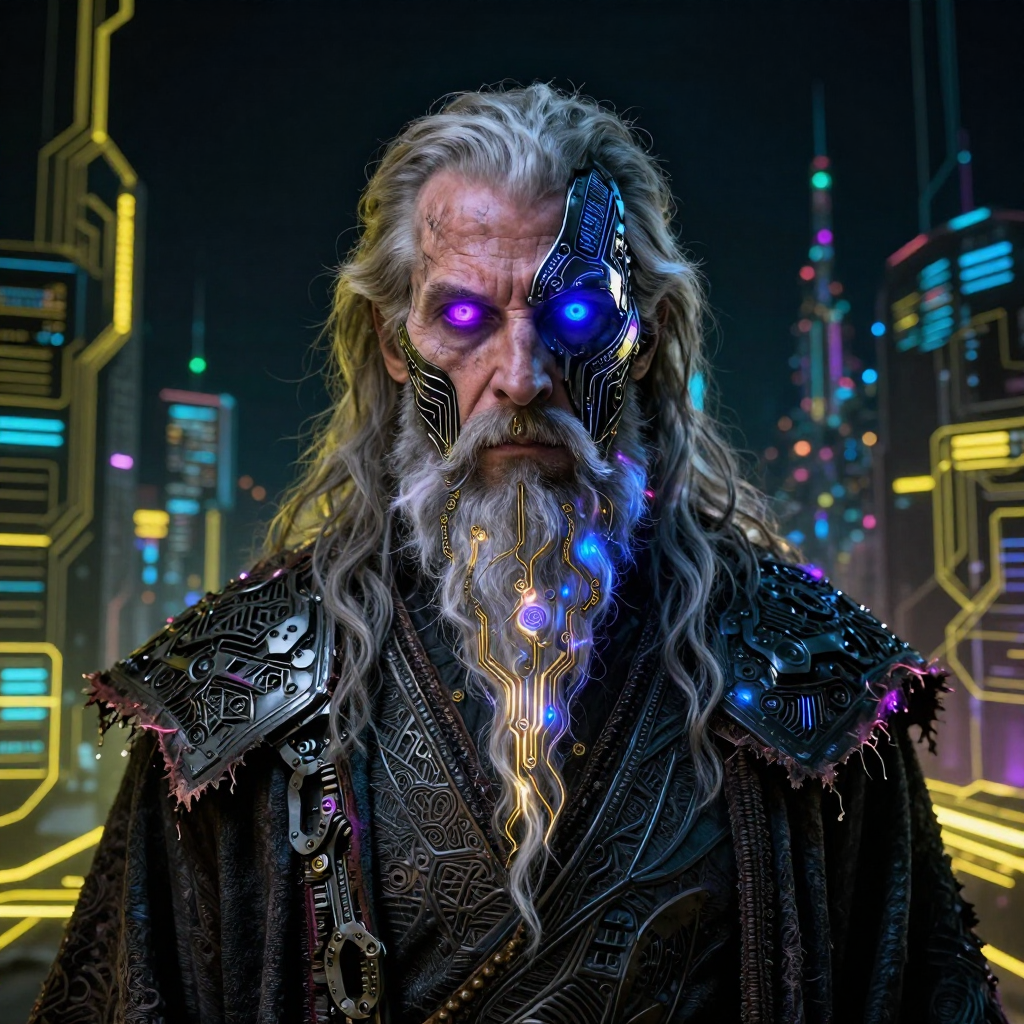

In [4]:
prompt = "a grizzled 60-year-old mage, his face a striking fusion of ancient mysticism and cutting-edge cyberware, staring directly into the camera with piercing, bioluminescent eyes that flicker between arcane violet and cold machine blue. His silver-streaked beard is woven with delicate gold circuitry, pulsing faintly with energy, while the left side of his face transitions seamlessly into sleek, blackened metal plating, etched with glowing runes that hum with latent power. His robe, a tattered mix of enchanted fabric and nano-weave armor, clings to his broad shoulders, its frayed edges crackling with unstable magic. Behind him, a sprawling microchip cityscape throbs with neon-yellow circuit patterns against an abyssal black void, the labyrinthine pathways mirroring the intricate scars and implants across his weathered skin. The air around him shimmers with distortion—part holographic spell matrix, part overheating processor—as if reality itself struggles to contain him."
image = pipe(
    prompt=prompt,
    height=1024,
    width=1024,
    num_inference_steps=9,
    guidance_scale=0.0,
    generator=torch.manual_seed(42),
).images[0]
display(image)